In [1]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra
using Plots
using Distributions
using Statistics
using Lux
using JLD2

In [2]:
η = 0.15

σf = 0.0e-2 # how much noise is added to f
σg = 0.0e-2 # How much noise is added to g
# Steers prox operators:
ρ_obj = 0.0

0.0

In [3]:
img = load("../reconstructions/1096.jpg")
img_f = img .|> Float64
img_f .-= 0.5
img_f .*= 2.0
img_f .= exp.(img_f) # Just an idea maybe EIT reconstruction is easier with this.

150×150 Matrix{Float64}:
 1.38471   1.39561   1.4066    1.4066    …  1.89499   1.88019   1.88019
 1.41768   1.42884   1.44009   1.44009      1.90992   1.90992   1.90992
 1.44009   1.45143   1.46286   1.46286      1.92495   1.92495   1.92495
 1.46286   1.47438   1.48599   1.48599      1.92495   1.92495   1.92495
 1.48599   1.49769   1.50948   1.50948      1.94011   1.94011   1.94011
 1.47438   1.48599   1.49769   1.49769   …  1.97078   1.97078   1.97078
 1.44009   1.45143   1.46286   1.46286      1.9863    1.9863    1.9863
 1.44009   1.45143   1.46286   1.46286      1.97078   1.9863    1.9863
 1.46286   1.46286   1.47438   1.48599      2.01771   2.00194   1.9863
 1.47438   1.48599   1.48599   1.49769      2.00194   2.00194   1.9863
 ⋮                                       ⋱                      
 0.367879  0.382593  0.388641  0.407368     0.388641  0.373696  0.388641
 0.394786  0.437162  0.385605  0.385605     0.394786  0.367879  0.373696
 0.385605  0.417066  0.42366   0.417066     0.39

In [4]:
itp = interpolate_array_2D(Float64.(img_f))

#interpolate_array_2D##0 (generic function with 1 method)

In [5]:
n = 63 
grid = generate_grid(Quadrilateral, (n, n));

In [6]:
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,1,0,3,∂Ω)

FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 1}(), [0.7872983346207417 0.44364916731037085 … 0.05635083268962915 0.012701665379258308; 0.09999999999999994 0.44364916731037085 … 0.05635083268962915 0.09999999999999999; 0.012701665379258296 0.05635083268962912 … 0.44364916731037085 0.7872983346207417; 0.09999999999999994 0.05635083268962912 … 0.44364916731037085 0.09999999999999999], [0.7872983346207417 0.44364916731037085 … 0.05635083268962915 0.012701665379258308; 0.099999999999999

In [7]:
cond_vec = project_function_to_fem(fe, itp; space=:σ)
cond_vec .= min.(max.(cond_vec, 1e-6), 2.8)

3969-element SparseArrays.SparseVector{Float64, Int64} with 3969 stored entries:
  [1   ]  =  1.43257
  [2   ]  =  1.4845
  [3   ]  =  1.46419
  [4   ]  =  1.47182
  [5   ]  =  1.49761
  [6   ]  =  1.5537
  [7   ]  =  1.59288
          ⋮
  [3962]  =  0.391354
  [3963]  =  0.405863
  [3964]  =  0.443788
  [3965]  =  0.403251
  [3966]  =  0.383249
  [3967]  =  0.386418
  [3968]  =  0.377171
  [3969]  =  0.382861

In [8]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [23]:
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:253
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i-1] = assemble_rhs_func(fe, itp)
end
G = zeros(fe.n,252)
for i in 1:252
    G[:,i] = rhs_dict[i]
end

In [24]:
fbm_true =  FerriteBlockMode(cond_vec, G, fe; block=false)

FerriteBlockMode(ModularEIT.BlockLAssembler(4, [0.25524077362757097 -0.06381019340689274 -0.12762038681378543 -0.06381019340689281; -0.06381019340689274 0.25524077362757147 -0.06381019340689284 -0.12762038681378587; -0.12762038681378543 -0.06381019340689284 0.2552407736275713 -0.063810193406893; -0.06381019340689281 -0.12762038681378587 -0.063810193406893 0.25524077362757164]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], sparse([1, 2, 3, 4, 1, 2, 3, 4, 5, 6  …  4030, 4031, 4032, 4094, 4095, 4096, 4031, 4032, 4095, 4096], [1, 1, 1, 1, 2, 2, 2, 2, 2, 2  …  4095, 4095, 4095, 4095, 4095, 4095, 4096, 4096, 4096, 4096], [0.9550479532649173, -0.2387619883162296, -0.4775239766324585, -0.23876198831622916, -0.2387619883162296, 1.944714705659659, -0.4861786764149203, -0.4775239766324585, -0.24741668809868, -0.49483337619737067  …  -0.12572368871325723, -0.12667203776352012, -0.12762038681378587, -0.06286184435662999, 0.5066881510540862

In [25]:
F = fbm_true.F
GS = copy(fe.down(fbm_true.G))
F, G , Σ = svd_on_modes(F,GS)

([-1.3651022150313705 -3.456669111863606 … -2.0608113459959135e-10 1.7431457145775017e-17; -1.3521818265658168 -3.4115576140546353 … -1.2507898387996713e-9 1.743145714449888e-17; … ; 12.287326815403825 5.707209341865827 … -1.2739122428633873e-9 1.7431457144688608e-17; 12.761754638758097 6.0004620125731725 … -3.7986208018143517e-10 1.7431457142658012e-17], [-0.019049704817560513 -0.061987732212115204 … 1.080340122402562e-9 0.06299407883487082; -0.018869402922880973 -0.061178752288851945 … -3.0669809623624438e-9 0.06299407883487361; … ; 0.1714669842633846 0.10234619630494314 … -4.301937834267596e-9 0.06299407883487049; 0.1780875097952142 0.10760504189069646 … -9.045881928362039e-10 0.06299407883487111], [71.66001807188646, 55.7637635276769, 31.55122007181819, 22.524672020918533, 20.01444471864472, 16.438409511489798, 15.1149509579078, 14.480175469876144, 11.362457224656245, 9.817115500100678  …  0.28153898627041724, 0.2791846744011368, 0.275400290049903, 0.2685883985130166, 0.26736575619

In [26]:
fbm = FerriteBlockMode(F, fe.up(G), fe)

FerriteBlockMode(ModularEIT.BlockLAssembler(4, [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], sparse([1, 2, 3, 4, 1, 2, 3, 4, 5, 6  …  4030, 4031, 4032, 4094, 4095, 4096, 4031, 4032, 4095, 4096], [1, 1, 1, 1, 2, 2, 2, 2, 2, 2  …  4095, 4095, 4095, 4095, 4095, 4095, 4096, 4096, 4096, 4096], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 4096, 4096), sparse([1, 2, 3, 4, 4097, 1, 2, 3, 4, 5  …  4087, 4088, 4089, 4090, 4091, 4092, 4093, 4094, 4095, 4096], [1, 1, 1, 1, 1, 2, 2, 2, 2, 2  …  4097, 4097, 4097, 4097, 4097, 4097, 4097, 4097, 4097, 4097], [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 4097, 4097), [-1.3651022150313705 -3.456669111863606 … -2.0608113459959135e-10 1.7431457145775017e-17; -1.3521818265658168 -3.4115576140546353 … -1.250789838

In [50]:
f, ∂f =  create_block_f∂f(fbm, fe;
                           nmodes=100, block=true,
                           gn=false)

(ModularEIT.var"#53#54"{Int64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, Base.RefValue{Bool}, Base.RefValue{Float64}, Base.RefValue{Union{Nothing, Vector{Float64}}}}(100, true, 1.0, nothing, 0.0, FerriteBlockMode(ModularEIT.BlockLAssembler(4, [0.6666667489994713 -0.16666668724986783 -0.33333337449973555 -0.166666687249868; -0.16666668724986783 0.6666667489994725 -0.1666666872498681 -0.3333333744997367; -0.33333337449973555 -0.1666666872498681 0.6666667489994722 -0.1666666872498685; -0.166666687249868 -0.3333333744997367 -0.1666666872498685 0.6666667489994731]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], sparse([1, 2, 3, 4, 1, 2, 3, 4, 5, 6  …  4030, 4031, 4032, 4094, 4095, 4096, 4031, 4032, 4095, 4096], [1, 1, 1, 1, 2, 2, 2, 2, 2, 2  …  4095, 4095, 4095, 4095, 4095, 4095, 4096, 4096, 4096, 4096], [0.6666666395823571, -0.16666665989558943, -0.3333333197911784, -0.16666665989558915, -

In [51]:
prox_obj = create_proximal_gradient_step(f,∂f,ρ_obj, fe.n_σ)

#94 (generic function with 1 method)

In [52]:
fbm

FerriteBlockMode(ModularEIT.BlockLAssembler(4, [0.6666667489994713 -0.16666668724986783 -0.33333337449973555 -0.166666687249868; -0.16666668724986783 0.6666667489994725 -0.1666666872498681 -0.3333333744997367; -0.33333337449973555 -0.1666666872498681 0.6666667489994722 -0.1666666872498685; -0.166666687249868 -0.3333333744997367 -0.1666666872498685 0.6666667489994731]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], sparse([1, 2, 3, 4, 1, 2, 3, 4, 5, 6  …  4030, 4031, 4032, 4094, 4095, 4096, 4031, 4032, 4095, 4096], [1, 1, 1, 1, 2, 2, 2, 2, 2, 2  …  4095, 4095, 4095, 4095, 4095, 4095, 4096, 4096, 4096, 4096], [0.6666666395823571, -0.16666665989558943, -0.3333333197911784, -0.16666665989558915, -0.16666665989558943, 1.3333332880990003, -0.33333332202475374, -0.3333333197911784, -0.1666666621291571, -0.33333332425832146  …  -0.33333327874304053, -0.3333333266213848, -0.3333333744997367, -0.16666663937152393, 1.3333333064855544, -0.

In [53]:
σ₁ = ones(fe.n_σ)


3969-element Vector{Float64}:
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

In [54]:
σᵢ, err, _ = prox_obj(σ₁) 

([1.4385700091165827, 1.501723401876947, 1.4965495323823748, 1.4897888900823553, 1.5076834868904958, 1.5487395322706359, 1.5607423906402837, 1.5906700552779451, 1.6277254437370092, 1.668919020506877  …  0.38865327301678976, 0.4086445168807043, 0.3912746762616764, 0.40622012156702675, 0.4438793605972158, 0.4030055114291479, 0.3832671017338953, 0.3862899107558852, 0.37720741604582697, 0.3828997605995482], 2.5871945811459297e-5, 0.0)

In [55]:
# Choose some starting sigma:

In [56]:
σ_img = log.(reshape(evaluate_at_points(ph, fe.dh_σ, σᵢ), (64, 64)))

64×64 Matrix{Float64}:
  0.36365    0.36365    0.38154   …   0.648092   0.650135   0.648466
  0.36365    0.36365    0.38154       0.648092   0.650135   0.648466
  0.406613   0.406613   0.354312      0.660425   0.631573   0.664465
  0.403162   0.403162   0.378559      0.689562   0.667207   0.6749
  0.398634   0.398634   0.355997      0.712056   0.690814   0.669903
  0.410574   0.410574   0.377377  …   0.725174   0.70823    0.67126
  0.437441   0.437441   0.439011      0.732127   0.723042   0.694181
  0.445162   0.445162   0.49808       0.735266   0.735517   0.716324
  0.464155   0.464155   0.539577      0.736162   0.745292   0.743585
  0.487184   0.487184   0.562476      0.73624    0.753601   0.770281
  ⋮                               ⋱                        
 -0.762714  -0.762714  -0.831124  …  -0.907535  -0.873063  -0.89491
 -0.799728  -0.799728  -0.803748     -0.981308  -0.984119  -0.938345
 -0.874296  -0.874296  -0.942383     -0.862915  -0.891997  -0.90086
 -0.890791  -0.890791  -1

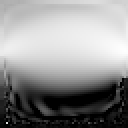

In [57]:
σ_img = Gray.(((σ_img) .*0.5) .+0.5)

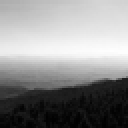

In [58]:
# cond_vec lives on the σ-space (fe.dh_σ), not the u-space (fe.dh) — must
# evaluate against fe.dh_σ to read the conductivity image back out.
cond_img = reshape(evaluate_at_points(ph, fe.dh_σ, cond_vec), (64, 64))
cond_img = Gray.(log.(cond_img) .*0.5 .+0.5)